# Regression, function-based — X/y as parameters

No hardcoded feature list, and no hardcoded target either. `test_target(train_df, test_df, target_col, numeric_features, categorical_features)` is the one-line entry point: pick any dollar field as the target, pick any columns as features, get a comparison matrix back. Anyone can write a new snippet calling it with different arguments — no copy-pasting blocks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('Claim_main.csv')
df.head()

,repair_id,claim_id,vehicle_id,repair_shop_contact_id,invoice_amount,estimate_amount,approved_amount,paid_amount,repair_start_date,repair_end_date,...,catastrophe_code,loss_date,reported_date,cost_type,cost_category,shop_city,shop_state,reserve_amount,is_repeat_vehicle,vehicle_claim_count
0,1,1,1798,209,5113.35,5831.11,4831.38,4871.05,2026-07-08,2026-07-25,...,NaN,2026-07-03,2026-07-07,Labor,Repair,Newark,NJ,4938.24,False,1
1,2,2,3026,12,826.96,1033.44,768.75,746.74,2026-06-21,2026-06-22,...,NaN,2026-06-16,2026-06-19,Paint,Repair,El Paso,TX,1326.82,False,1
2,3,3,6013,88,1091.33,1038.62,964.03,949.65,2025-02-18,2025-02-25,...,NaN,2025-02-13,2025-02-16,Paint,Repair,Orlando,FL,731.75,False,1
3,4,4,64,164,1754.45,1711.16,1811.61,1789.23,2026-02-20,2026-02-22,...,NaN,2026-02-14,2026-02-23,Paint,Repair,Newark,NJ,1682.03,False,1
4,5,5,4714,106,1285.22,1151.50,1104.23,1153.84,2025-03-10,2025-03-18,...,NaN,2025-03-04,2025-03-11,Parts,Supplemental,Springfield,IL,1235.65,True,6


## Feature engineering (one-time, not part of the iteration loop)

These are data cleanup/derivation, not feature *selection* — done once regardless of which columns you later choose to model with.

In [3]:
SEVERITY_ORDER = {"Minor": 0, "Moderate": 1, "Severe": 2, "Total Loss": 3}
df["damage_severity_ordinal"] = df["damage_severity"].map(SEVERITY_ORDER)
df["initial_damage_assessment_ordinal"] = df["initial_damage_assessment"].map(SEVERITY_ORDER)
df["airbags_deployed"] = df["airbags_deployed"].astype(int)
df["is_supplemental"] = (df["cost_category"] == "Supplemental").astype(int)
df["has_catastrophe_code"] = df["catastrophe_code"].notna().astype(int)

df["repair_start_date"] = pd.to_datetime(df["repair_start_date"])
df["repair_end_date"] = pd.to_datetime(df["repair_end_date"])
df["repair_duration_days"] = (df["repair_end_date"] - df["repair_start_date"]).dt.days.clip(lower=1)
df["vehicle_age"] = pd.Timestamp.now().year - df["vehicle_year"]

## One-time train/test split

Done once on the *full* candidate column pool, including all four dollar fields (`invoice_amount`, `estimate_amount`, `approved_amount`, `paid_amount`) so any of them can be picked as the target later without re-splitting.

In [4]:
DOLLAR_FIELDS = ["invoice_amount", "estimate_amount", "approved_amount", "paid_amount"]
CANDIDATE_NUMERIC = ["estimate_amount", "vehicle_age", "liability_percentage", "repair_duration_days", "vehicle_claim_count",
    "damage_severity_ordinal", "initial_damage_assessment_ordinal", "airbags_deployed", "is_supplemental",
    "has_catastrophe_code", "reserve_amount"]
CANDIDATE_CATEGORICAL = ["make", "model", "claim_severity", "incident_state", "loss_cause", "point_of_impact"]

split_cols = list(dict.fromkeys(CANDIDATE_NUMERIC + CANDIDATE_CATEGORICAL + ["repair_shop_contact_id"] + DOLLAR_FIELDS))
train_df, test_df = train_test_split(df[split_cols], test_size=0.2, random_state=42)

## The reusable functions

**Target-related** (new, dynamic — this is the part that used to be hardcoded):
- `add_shop_avg(train_df, test_df, target_col)` — leakage-safe shop average for *any* target column, names the new column `shop_avg_<target_col>`, returns that name.
- `prepare_target(train_df, test_df, target_col)` — calls `add_shop_avg`, returns `(y_train, y_test, shop_avg_col_name)`.
- `test_target(train_df, test_df, target_col, numeric_features, categorical_features)` — the one-line entry point: prepares the target, fits and compares all 7 models, returns the comparison matrix. This is what "anyone" should call to try a new target or feature set.

**Model-related** (unchanged from before):
- `tune_models(X_train, y_train, numeric_features, categorical_features)` — `RandomizedSearchCV` per model, returns a `params` dict.
- `fit_all_models(X_train, y_train, numeric_features, categorical_features, params=None)` — fits all 7 models.
- `compare_models(fitted_models, X_test, y_test, numeric_features, categorical_features)` — MAE/RMSE/R2 matrix.
- `run_comparison(...)` — fits + compares in one call, for when you already have `y_train`/`y_test` prepared.

In [5]:
def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ])

DEFAULT_PARAMS = {
    "Ridge": {"alpha": 100.0},
    "RandomForest": {"n_estimators": 200, "min_samples_leaf": 5, "max_depth": None},
    "ExtraTrees": {"n_estimators": 100, "min_samples_leaf": 2, "max_depth": 10},
    "GradientBoosting": {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.1},
    "HistGradientBoosting": {},
    "LightGBM": {"n_estimators": 100, "max_depth": 10, "learning_rate": 0.05, "num_leaves": 31},
    "XGBoost": {"n_estimators": 100, "max_depth": 5, "learning_rate": 0.05},
}

MODEL_GRIDS = {
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
    "RandomForest": {"model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 5]},
    "ExtraTrees": {"model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20], "model__min_samples_leaf": [1, 2, 5]},
    "GradientBoosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
    "HistGradientBoosting": {"model__max_iter": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [None, 5, 10]},
    "LightGBM": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [-1, 5, 10], "model__num_leaves": [15, 31, 63]},
    "XGBoost": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [3, 5, 7]},
}

def make_estimator(name, params):
    if name == "Ridge": return Ridge(**params)
    elif name == "RandomForest": return RandomForestRegressor(random_state=42, **params)
    elif name == "ExtraTrees": return ExtraTreesRegressor(random_state=42, **params)
    elif name == "GradientBoosting": return GradientBoostingRegressor(random_state=42, **params)
    elif name == "HistGradientBoosting": return HistGradientBoostingRegressor(random_state=42, **params)
    elif name == "LightGBM": return LGBMRegressor(random_state=42, verbose=-1, **params)
    elif name == "XGBoost": return XGBRegressor(random_state=42, **params)

def fit_all_models(X_train, y_train, numeric_features, categorical_features, params=None):
    params = params or DEFAULT_PARAMS
    fitted = {}
    for name in MODEL_GRIDS:
        est = make_estimator(name, params.get(name, {}))
        pipe = Pipeline([("pre", build_preprocessor(numeric_features, categorical_features)), ("model", est)])
        pipe.fit(X_train[numeric_features + categorical_features], y_train)
        fitted[name] = pipe
    return fitted

In [6]:
def add_shop_avg(train_df, test_df, target_col, shop_id_col="repair_shop_contact_id"):
    shop_avg = train_df.groupby(shop_id_col)[target_col].mean()
    global_avg = train_df[target_col].mean()
    col_name = f"shop_avg_{target_col}"
    train_df[col_name] = train_df[shop_id_col].map(shop_avg)
    test_df[col_name] = test_df[shop_id_col].map(shop_avg).fillna(global_avg)
    return col_name

def prepare_target(train_df, test_df, target_col, shop_id_col="repair_shop_contact_id"):
    shop_avg_col = add_shop_avg(train_df, test_df, target_col, shop_id_col)
    return train_df[target_col], test_df[target_col], shop_avg_col

In [7]:
def tune_models(X_train, y_train, numeric_features, categorical_features, n_iter=6, cv=3, random_state=42):
    best_params = {}
    for name, grid in MODEL_GRIDS.items():
        pipe = Pipeline([("pre", build_preprocessor(numeric_features, categorical_features)), ("model", make_estimator(name, {}))])
        n = min(n_iter, int(np.prod([len(v) for v in grid.values()])))
        search = RandomizedSearchCV(pipe, grid, n_iter=n, cv=cv, scoring="neg_mean_absolute_error", random_state=random_state, n_jobs=4)
        search.fit(X_train[numeric_features + categorical_features], y_train)
        best_params[name] = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
    return best_params

In [8]:
def compare_models(fitted_models, X_test, y_test, numeric_features, categorical_features):
    rows = []
    preds = {}
    for name, model in fitted_models.items():
        pred = model.predict(X_test[numeric_features + categorical_features])
        preds[name] = pred
        rows.append({"model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": mean_squared_error(y_test, pred) ** 0.5,
            "R2": r2_score(y_test, pred)})
    comparison_df = pd.DataFrame(rows).set_index("model")
    return comparison_df, preds

In [9]:
def run_comparison(X_train, X_test, y_train, y_test, numeric_features, categorical_features, params=None):
    fitted = fit_all_models(X_train, y_train, numeric_features, categorical_features, params=params)
    comparison_df, preds = compare_models(fitted, X_test, y_test, numeric_features, categorical_features)
    return comparison_df, fitted, preds

def test_target(train_df, test_df, target_col, numeric_features, categorical_features, params=None):
    y_train, y_test, shop_avg_col = prepare_target(train_df, test_df, target_col)
    features = [c for c in numeric_features if not c.startswith("shop_avg_")] + [shop_avg_col]
    comparison_df, fitted, preds = run_comparison(train_df, test_df, y_train, y_test, features, categorical_features, params=params)
    return comparison_df, fitted, preds

In [10]:
def plot_r2(comparison_df, title=""):
    fig, ax = plt.subplots(figsize=(8, 4))
    comparison_df["R2"].plot(kind="bar", ax=ax)
    ax.set_ylim(0, 1)
    ax.set_ylabel("R2")
    ax.set_title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

## Default target setup (for Iterations 1-4 below, which use `run_comparison` directly)

In [11]:
DEFAULT_TARGET = "invoice_amount"
y_train, y_test, SHOP_AVG_COL = prepare_target(train_df, test_df, DEFAULT_TARGET)
X_train, X_test = train_df, test_df

## Iteration 1 — baseline features (no new fields)

In [12]:
numeric_1 = ["estimate_amount", "vehicle_age", "liability_percentage", "repair_duration_days", "vehicle_claim_count",
    "damage_severity_ordinal", SHOP_AVG_COL]
categorical_1 = ["make", "model", "claim_severity", "incident_state", "loss_cause"]

comparison_1, fitted_1, preds_1 = run_comparison(X_train, X_test, y_train, y_test, numeric_1, categorical_1)
comparison_1

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,579.298589,995.184944,0.897385
RandomForest,524.921048,960.926613,0.904328
ExtraTrees,504.850049,904.363503,0.915260
GradientBoosting,501.979296,901.206502,0.915851
HistGradientBoosting,502.702484,930.946188,0.910205
LightGBM,504.839239,922.921253,0.911746
XGBoost,510.915204,928.288915,0.910717


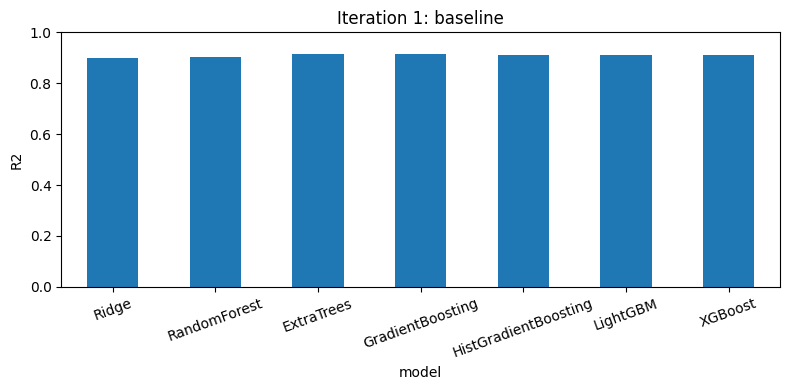

In [13]:
plot_r2(comparison_1, "Iteration 1: baseline")

## Iteration 2 — add the validated new fields

In [14]:
numeric_2 = numeric_1 + ["initial_damage_assessment_ordinal", "airbags_deployed", "is_supplemental", "has_catastrophe_code", "reserve_amount"]
categorical_2 = categorical_1 + ["point_of_impact"]

comparison_2, fitted_2, preds_2 = run_comparison(X_train, X_test, y_train, y_test, numeric_2, categorical_2)
comparison_2

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,546.816171,938.401550,0.908761
RandomForest,457.275433,852.500309,0.924701
ExtraTrees,440.907679,808.238846,0.932317
GradientBoosting,435.065986,779.522400,0.937041
HistGradientBoosting,412.472164,783.046129,0.936470
LightGBM,433.277132,803.439935,0.933118
XGBoost,447.908895,807.179368,0.932494


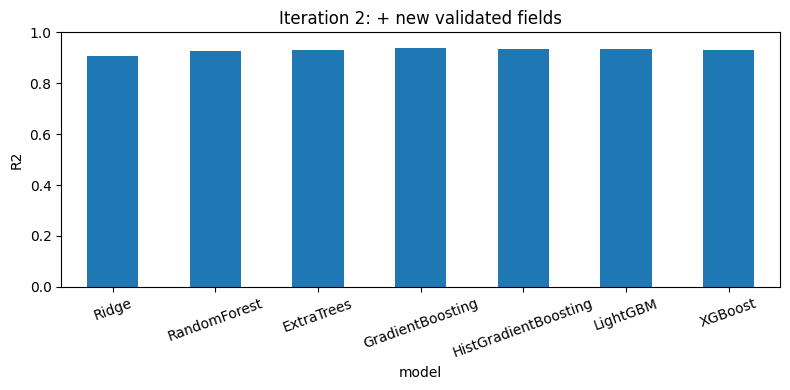

In [15]:
plot_r2(comparison_2, "Iteration 2: + new validated fields")

## Iteration 3 — same as Iteration 2, but drop `estimate_amount`

Testing the circularity concern directly: does removing the field that dominates (and creates near-leakage) change results much?

In [16]:
numeric_3 = [c for c in numeric_2 if c != "estimate_amount"]
categorical_3 = categorical_2

comparison_3, fitted_3, preds_3 = run_comparison(X_train, X_test, y_train, y_test, numeric_3, categorical_3)
comparison_3

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,784.406844,1316.326541,0.820473
RandomForest,495.879797,1062.313547,0.883075
ExtraTrees,577.831712,1040.589975,0.887808
GradientBoosting,446.843991,892.939411,0.917387
HistGradientBoosting,401.353580,890.414018,0.917854
LightGBM,446.246056,941.879467,0.908083
XGBoost,509.306988,995.123259,0.897398


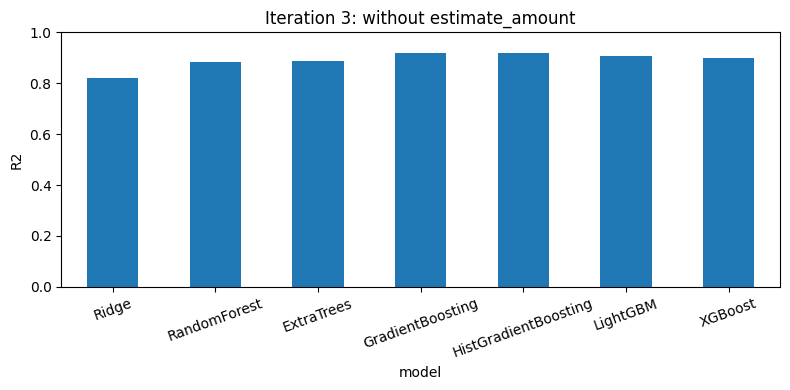

In [17]:
plot_r2(comparison_3, "Iteration 3: without estimate_amount")

## Iteration 4 — Iteration 2's features, but tuned

Same columns as Iteration 2, this time with `tune_models()` run first instead of the fixed `DEFAULT_PARAMS`.

In [18]:
tuned_params_2 = tune_models(X_train, y_train, numeric_2, categorical_2)
tuned_params_2

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/skle

{'Ridge': {'alpha': 100.0},
 'RandomForest': {'n_estimators': 200,
  'min_samples_leaf': 1,
  'max_depth': None},
 'ExtraTrees': {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': None},
 'GradientBoosting': {'n_estimators': 200,
  'max_depth': 3,
  'learning_rate': 0.1},
 'HistGradientBoosting': {'max_iter': 200,
  'max_depth': 5,
  'learning_rate': 0.1},
 'LightGBM': {'num_leaves': 63,
  'n_estimators': 200,
  'max_depth': 10,
  'learning_rate': 0.1},
 'XGBoost': {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}}

In [19]:
comparison_4, fitted_4, preds_4 = run_comparison(X_train, X_test, y_train, y_test, numeric_2, categorical_2, params=tuned_params_2)
comparison_4

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,546.816171,938.401550,0.908761
RandomForest,443.528392,837.862163,0.927264
ExtraTrees,395.979874,776.953741,0.937455
GradientBoosting,435.065986,779.522400,0.937041
HistGradientBoosting,403.869091,767.509882,0.938966
LightGBM,402.239753,773.723489,0.937974
XGBoost,406.706163,775.734543,0.937651


## Iteration 5 — same features as Iteration 2, but target = `approved_amount`

This is the one-line version now — `test_target` handles preparing the target, the shop average, and running all 7 models. No manual copy-pasting of the shop-average block needed.

In [20]:
comparison_5, fitted_5, preds_5 = test_target(train_df, test_df, "approved_amount", numeric_2, categorical_2)
comparison_5

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,479.762545,833.334067,0.914568
RandomForest,425.648167,829.793032,0.915293
ExtraTrees,400.032867,723.450029,0.935613
GradientBoosting,383.526835,692.547667,0.940996
HistGradientBoosting,356.056726,663.087875,0.945909
LightGBM,392.638648,706.114506,0.938662
XGBoost,413.634182,756.892874,0.929523


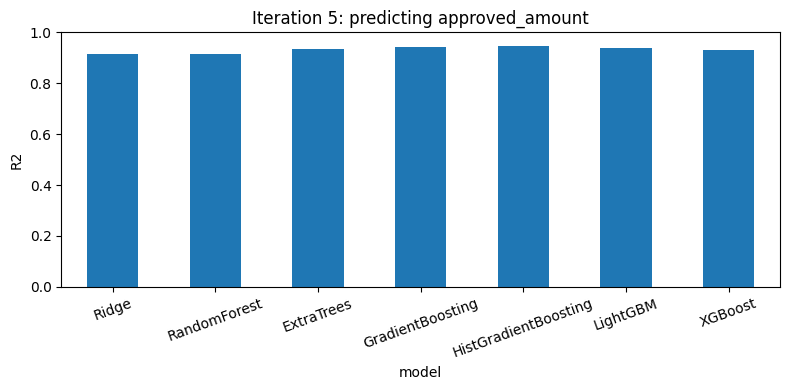

,iter2_predict_invoice,iter5_predict_approved
model,,
Ridge,0.908761,0.914568
RandomForest,0.924701,0.915293
ExtraTrees,0.932317,0.935613
GradientBoosting,0.937041,0.940996
HistGradientBoosting,0.936470,0.945909
LightGBM,0.933118,0.938662
XGBoost,0.932494,0.929523


In [21]:
plot_r2(comparison_5, "Iteration 5: predicting approved_amount")
pd.DataFrame({"iter2_predict_invoice": comparison_2["R2"], "iter5_predict_approved": comparison_5["R2"]})

## Iteration 6 — proving the point: target = `paid_amount`, written from scratch in one line

This is the "anyone can write a new snippet" test — no setup beyond calling `test_target` with a different target column.

In [22]:
comparison_6, fitted_6, preds_6 = test_target(train_df, test_df, "paid_amount", numeric_2, categorical_2)
comparison_6

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,478.237366,832.922886,0.914161
RandomForest,427.394173,825.875540,0.915608
ExtraTrees,402.972623,725.427657,0.934888
GradientBoosting,386.339570,696.787940,0.939928
HistGradientBoosting,355.972795,678.920927,0.942969
LightGBM,396.554896,740.711992,0.932115
XGBoost,413.649410,759.349448,0.928656


## Iteration 7: Target = approved_amount and no estimate_amount in the fields

In [27]:
comparison_7, fitted_7, preds_7 = test_target(train_df, test_df, "approved_amount", numeric_3, categorical_3)
comparison_7

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,MAE,RMSE,R2
model,,,
Ridge,636.932556,1073.994699,0.858099
RandomForest,391.804874,875.340427,0.905739
ExtraTrees,468.011228,815.747769,0.918136
GradientBoosting,349.800449,659.210175,0.946540
HistGradientBoosting,309.657932,617.914993,0.953028
LightGBM,351.146899,701.297626,0.939496
XGBoost,412.631636,798.870715,0.921489


## All iterations, side by side (R2 only)

In [26]:
side_by_side = pd.DataFrame({
    "iter1_baseline": comparison_1["R2"],
    "iter2_plus_new_fields": comparison_2["R2"],
    "iter3_no_estimate": comparison_3["R2"],
    "iter4_tuned": comparison_4["R2"],
    "iter5_predict_approved": comparison_5["R2"],
    "iter6_predict_paid": comparison_6["R2"],
    "iter7_approved_no_estimate": comparison_7["R2"]
})
side_by_side

,iter1_baseline,iter2_plus_new_fields,iter3_no_estimate,iter4_tuned,iter5_predict_approved,iter6_predict_paid,iter7_approved_no_estimate
model,,,,,,,
Ridge,0.897385,0.908761,0.820473,0.908761,0.914568,0.914161,0.858099
RandomForest,0.904328,0.924701,0.883075,0.927264,0.915293,0.915608,0.905739
ExtraTrees,0.915260,0.932317,0.887808,0.937455,0.935613,0.934888,0.918136
GradientBoosting,0.915851,0.937041,0.917387,0.937041,0.940996,0.939928,0.946540
HistGradientBoosting,0.910205,0.936470,0.917854,0.938966,0.945909,0.942969,0.953028
LightGBM,0.911746,0.933118,0.908083,0.937974,0.938662,0.932115,0.939496
XGBoost,0.910717,0.932494,0.897398,0.937651,0.929523,0.928656,0.921489
